In [1]:
Filename = "sample.txt"
with open(Filename, "r") as f:
    print(f.read())

Name    ODI    Test
Tamim    30    35
Mushi    40    30
Mahmud    10    30
Tamim    10    20
Tamim    30    60
Mahmud    100    10


In [8]:
fr = open("sample.txt", "r")

fr.readline()    #read the header
lines = fr.readlines()
players = {}

for line in lines:
    line = line.strip()         # delete whitespaces
    word = line.split("    ")   # word = list of the words in a line
    pl = word[0]
    if pl not in players:
        players[pl] = 0

for pl in players:
    print(pl)    

Tamim
Mushi
Mahmud


In [1]:
# Find average run of all player
def avg(ls):
    sum = 0.0
    for i in range(len(ls)):
        sum += ls[i]    
    return sum/len(ls)


fr = open("sample.txt", "r")

fr.readline()    #read the header
lines = fr.readlines()
players = {}    #initialize a dict

for line in lines:
    line = line.strip()         # delete whitespaces
    word = line.split("    ")   # word = list of the words in a line
    pl = word[0]
    run = float(word[1])        # run = list of runs of a player

    if pl not in players:
        players[pl] = []
    players[pl].append(run)

for player in players:
    average = avg(players[player])
    print(player, average)


Tamim 23.333333333333332
Mushi 40.0
Mahmud 55.0


In [ ]:
#list as value in a dictionary
def maxrun(ls):
    return int(max(ls))


fr = open("sample.txt", "r")

fr.readline()    #read the header
lines = fr.readlines()
fr.close()
players = {}    #initialize a dict

for line in lines:
    line = line.strip()         # delete whitespaces
    word = line.split("    ")   # word = list of the words in a line
    pl = word[0]
    run = float(word[1])        # run = list of runs of a player

    if pl not in players:
        players[pl] = []
    players[pl].append(run)

print("Name", "\tMaxOdiRun")
for player in players:
    print(player,"\t", maxrun(players[player]))


Name 	MaxOdiRun
Tamim 	 30
Mushi 	 40
Mahmud 	 100


In [24]:
# Nested dictionary
def maxrun(ls):
    return int(max(ls))


fr = open("sample.txt", "r")

fr.readline()    #read the header
lines = fr.readlines()
fr.close()
players = {}    #initialize a dict

for line in lines:
    line = line.strip()         # delete whitespaces
    word = line.split("    ")   # word = list of the words in a line
    pl = word[0]
    odirun = float(word[1])        # Odi run = list of odi runs of a player
    testrun = float(word[1])           # Test run = list of test runs of a player

    if pl not in players:
        players[pl] = {}
        players[pl]["ODI"] = []
        players[pl]["Test"] = []
    players[pl]["ODI"].append(odirun)
    players[pl]["Test"].append(testrun)

print("Player\tMaxOdiRun\tMaxTestRun")
for player in players:
    print(player,"\t", maxrun(players[player]["ODI"]),"\t\t", maxrun(players[player]["Test"])), 

Player	MaxOdiRun	MaxTestRun
Tamim 	 30 		 30
Mushi 	 40 		 40
Mahmud 	 100 		 100


<h4> Using real cricket data </h4>

In [32]:
fr = open("cricketdata/mushfiq/2015.txt", "r")

#ignore header
fr.readline()

lines = fr.readlines()
for line in lines:
    data = line.split("\t")
    print(data[5])


71 
36 
60 
89 
15 
27 
106 
65 
49* 
14 
31 
24 
24 
- 
- 
107 
21 
28 


In [37]:
#Mushfiq's average in 2015
fr = open("cricketdata/mushfiq/2015.txt", "r")

#ignore header
fr.readline()

lines = fr.readlines()
sum = 0.0
no_of_matches = 0
excp = 0

for line in lines:
    data = line.split("\t")

    try:    
        if "*" in data[5]:
            parsed = data[5].split("*")
            run = float(parsed[0]) 
        else:
            run = float(data[5])
            no_of_matches += 1

        sum += run

    except:
        print(data[5])
        excp += 1
        pass    # lines that give runtime error will be ignored
    
print("Total Exception: ", excp)
print("Average", sum/no_of_matches)

- 
- 
Total Exception:  2
Average 51.13333333333333


In [6]:
#Mushfiq's average over the years

def score(file):
    year = file.split("/")
    year = year[2][0:-4]


    fr = open(file, "r")
    #ignore header
    fr.readline()

    lines = fr.readlines()
    sum = 0.0
    no_of_matches = 0

    for line in lines:
        data = line.split("\t")

        try:    
            if "*" in data[5]:
                parsed = data[5].split("*")
                run = float(parsed[0]) 
            else:
                run = float(data[5])
                no_of_matches += 1

            sum += run

        except:
            pass    # lines that give runtime error will be ignored

    print(year+"'s", "Average", sum/no_of_matches)
    fr.close()




files = ["2015.txt","2016.txt","2017.txt","2018.txt","2019.txt"]
for file in files:
    score("cricketdata/Mushfiq/"+file)

    


2015's Average 51.13333333333333
2016's Average 44.25
2017's Average 45.8
2018's Average 55.0
2019's Average 15.333333333333334


In [27]:
# which bowler took out mushfiq most in these years?
bowlers = {}

def outbybowler(file):

    fr = open(file, "r")

    #ignore header
    fr.readline()
    lines = fr.readlines()

    for line in lines:
        data = line.split("\t")
        bowler = data[4].split(" b ")
        """if ("not out" in bowler[-1] or 
            "did not bat" in bowler[-1] or 
            "run out" in bowler[-1]):
             continue"""
        
        if len(bowler) <2:
            continue
        if bowler[1] not in bowlers: #if the last item(bowler's name) is not in the dictionary
            bowlers[bowler[1]] = 1
        else:
            bowlers[bowler[1]] += 1 


    fr.close()


files = ["2015.txt","2016.txt","2017.txt","2018.txt","2019.txt"]
for file in files:
    outbybowler("cricketdata/Tamim/"+file)

sorted_list = sorted(bowlers.items(), key = lambda x: x[1], reverse = True)
print(sorted_list)
for bowler in sorted_list:
    print(bowler[0],"\t",bowler[1],"\n")

[('J D S Neesham ', 3), ('T G Southee ', 3), ('D Bishoo ', 3), ('T A Boult ', 2), ('D S Kulkarni ', 2), ('A G Cremer ', 2), ('Mirwais Ashraf ', 2), ('J H Davey ', 1), ('J M Anderson ', 1), ('U T Yadav ', 1), ('Wahab Riaz ', 1), ('Junaid Khan ', 1), ('R Ashwin ', 1), ('Sikandar Raza ', 1), ('T Panyangara ', 1), ('Mohammad Nabi ', 1), ('J T Ball ', 1), ('C R Woakes ', 1), ('A U Rashid ', 1), ('C B R L S Kumara ', 1), ('K M D N Kulasekara ', 1), ("K J O'Brien ", 1), ('M J Santner ', 1), ('L E Plunkett ', 1), ('M A Starc ', 1), ('D Pretorius ', 1), ('A Dananjaya ', 1), ('R A S Lakmal ', 1), ('P V D Chameera ', 1), ('R L Chase ', 1), ('M J Henry ', 1)]
J D S Neesham  	 3 

T G Southee  	 3 

D Bishoo  	 3 

T A Boult  	 2 

D S Kulkarni  	 2 

A G Cremer  	 2 

Mirwais Ashraf  	 2 

J H Davey  	 1 

J M Anderson  	 1 

U T Yadav  	 1 

Wahab Riaz  	 1 

Junaid Khan  	 1 

R Ashwin  	 1 

Sikandar Raza  	 1 

T Panyangara  	 1 

Mohammad Nabi  	 1 

J T Ball  	 1 

C R Woakes  	 1 

A U Rash

In [2]:
#List all the files from a directory
import os

files = os.listdir("cricketdata/mushfiq/")
print(files)

['2015.txt', '2016.txt', '2017.txt', '2018.txt', '2019.txt']


In [8]:
count = 0
for file in files:
    fr = open("cricketdata/mushfiq/"+file, "r")

    #ignore header
    line = fr.readline()
    while 1:
        line = fr.readline().strip()
        if len(line)<3:
            break
        if "run out" in line:
            print (line)
            count += 1

print("Total run out: ", count)


11 	21/06/2015 	India 	Shere Bangla National Stadium 	run out 	31 	34 	91.18 	  	563 	56.30 	107.24
16 	07/11/2015 	Zimbabwe 	Shere Bangla National Stadium 	run out 	107 	109 	98.17 	  	718 	55.23 	102.28
11 	23/09/2018 	Afghanistan 	Sheikh Zayed Stadium 	run out 	33 	52 	63.46 	  	450 	45.00 	84.11
Total run out:  3


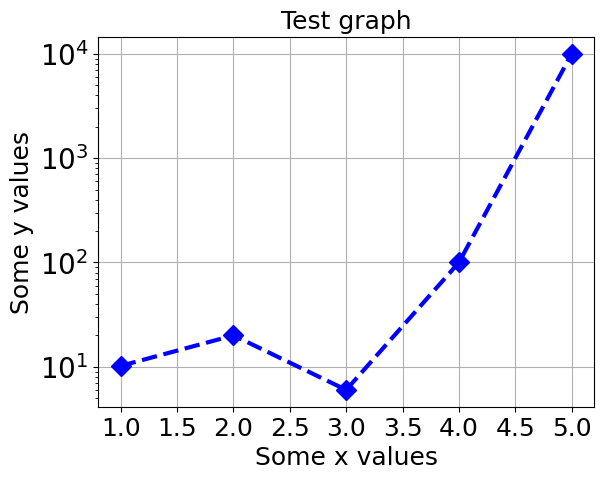

In [3]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)

x= [1,2,3,4,5]
y=[10.2,20,6,100,10000]

line = plt.plot(x,y)
plt.setp(line, color = "b", linewidth = 3, ls = "--",
         marker = "D", markersize = "10")

for label in ax.get_xticklabels():
    label.set_fontsize(18)

for label in ax.get_yticklabels():
    label.set_fontsize(20)

plt.title("Test graph", fontsize = 18)
plt.xlabel("Some x values", fontsize = 18)
plt.ylabel("Some y values", fontsize = 18)

plt.grid()

#ax.set_ylim(5,105)
#ax.set_xlim(0,6)
ax.set_yscale("log")

plt.show()

In [39]:
#CDF
values = [10,20,1,1,0,5,5,6,7,10]

total = len(values)
max_run = max(values)
count = [0.0]*(max_run+1) #initialize a list with 21 zeros

for v in values:
    count[v] += 1.0
print(count)


cdf = []
prev_sum = 0.0

for el in count:
    pr = (el/total) + prev_sum
    cdf.append(pr)
    prev_sum = pr
print(cdf)

[1.0, 2.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]
[0.1, 0.30000000000000004, 0.30000000000000004, 0.30000000000000004, 0.30000000000000004, 0.5, 0.6, 0.7, 0.7, 0.7, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.8999999999999999, 0.9999999999999999]
